# Poisonous Mushroom Classification - Modelling
**Group G · Dataset Version 44**
**Team:** Mariia Triapitsina · Illia Solovei · Sophia Hmyria

Chapter 2 of 2.

EDA and data forensics here: [Chapter 1: EDA](./01_eda.ipynb)

Data repairs implementations:
[preprocessing.py](./preprocessing.py).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (OneHotEncoder, OrdinalEncoder, PolynomialFeatures,
                                   StandardScaler, RobustScaler)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import (GridSearchCV, RandomizedSearchCV, cross_val_predict,
                                     TunedThresholdClassifierCV, FixedThresholdClassifier)
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay,
                             f1_score, precision_score, recall_score, roc_auc_score,
                             RocCurveDisplay, PrecisionRecallDisplay)

from preprocessing import (MushroomRepair, load_split,
                           NUM_REPAIRED, CATEGORICAL_LR, CATEGORICAL_ET, CATEGORICAL_HGB)

X_train, X_test, y_train, y_test = load_split()

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Poisonous in train: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Poisonous in test:  {y_test.sum()} ({y_test.mean()*100:.1f}%)")

Train: (8472, 8)  |  Test: (2118, 8)
Poisonous in train: 1932 (22.8%)
Poisonous in test:  484 (22.9%)


## Preprocessing Pipeline

**Numeric repairs** are applied to `cap-diameter`, `stem-height` and `stem-width` features. The corruptions repairs are targetting were documented in [Chapter 1](./01_eda.ipynb). Moreover, the ratio features were added.

Because 96% of rows have at least one missing value, **imputation is unavoidable and must be done inside the pipeline** so that no information from validation or test folds leaks into training.

- **Numeric** (`cap-diameter`, `stem-height`, `stem-width`): median imputation, robust to residual outliers.
- **Categorical**: missing values encoded as their own category (`fill_value="missing"`). Given that `stem-root` is 84% missing, absence of information is itself predictive.

Notice, **categorical features differ per model.** E.g. Logistic Regression drops `season`, Extra Trees drops both `season` and `stem-root` and Hist Gradient keeps them all in tact. All gathered into distict clusters for each model in [preprocessing.py](./preprocessing.py).

## Model Selection and Tuning

We compared three model families. We used F1 as the main cross-validation metric because it balances precision and recall. Since this is a safety-sensitive task, we report recall for the poisonous class separately and interpret it as the most important error-specific metric.

The procedure stays the same across all models.
1. Search hyperparameters with CV
1. Tune the decision threshold on the training folds
1. Then freeze both into a `FixedThresholdClassifier` for inference

### Model 1 - Logistic Regression

Linear model with L1/L2 regularisation and polynomial interaction terms on the repaired numeric features.

#### Tuning observations
We searched C in `[0.01, 0.1, 1.0, 10.0, 100.0]`. Done for both L1 and L2.

Noticed increased recall without proportional validation improvement was shown across `C` values more higher. Which meant for us overfitting on a small and noicy numeric space.

Best `C` settled within 0.1 to 1.0 range.

In [3]:
num_pipe_lr = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("poly_feature", PolynomialFeatures(degree=2, interaction_only=True)),
    ("std_scaler", StandardScaler()),
])
cat_pipe_lr = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])
prep_lr = ColumnTransformer([
    ("num", num_pipe_lr, NUM_REPAIRED),
    ("cat", cat_pipe_lr, CATEGORICAL_LR),
])

lr_pipe = Pipeline([
    ("repair", MushroomRepair()),
    ("preprocessor", prep_lr),
    ("classifier", LogisticRegression(class_weight="balanced", max_iter=5000)),
])

lr_param_grid = {
    "classifier__C": [0.01, 0.1, 1.0, 10.0, 100.0],
    "classifier__penalty": ["l1", "l2"],
    "classifier__solver": ["saga"],
    "preprocessor__num__imputer__strategy": ["mean", "median"],
    "preprocessor__cat__imputer__strategy": ["most_frequent", "constant"],
}

lr_search = GridSearchCV(
    lr_pipe, param_grid=lr_param_grid, cv=5, scoring="f1",
    n_jobs=-1, return_train_score=True, verbose=1,
)
lr_search.fit(X_train, y_train)

print("Best CV F1: ", round(lr_search.best_score_, 4))
print("Best params:", lr_search.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max

Best CV F1:  0.4839
Best params: {'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'saga', 'preprocessor__cat__imputer__strategy': 'constant', 'preprocessor__num__imputer__strategy': 'median'}


In [4]:
lr_best = lr_search.best_estimator_

lr_tuned = TunedThresholdClassifierCV(
    estimator=lr_best, scoring="f1", response_method="predict_proba",
    thresholds=100, cv=5, refit=True, n_jobs=-1, store_cv_results=True,
)
lr_tuned.fit(X_train, y_train)
lr_threshold = lr_tuned.best_threshold_
print("Logistic Regression best threshold:", round(lr_threshold, 4))

lr_grid = FixedThresholdClassifier(
    estimator=FrozenEstimator(lr_best), threshold=lr_threshold,
    pos_label=1, response_method="predict_proba",
)
lr_grid.fit(X_train, y_train)

Logistic Regression best threshold: 0.5252


FixedThresholdClassifier(estimator=FrozenEstimator(estimator=Pipeline(steps=[('repair',
                                                                              MushroomRepair()),
                                                                             ('preprocessor',
                                                                              ColumnTransformer(transformers=[('num',
                                                                                                               Pipeline(steps=[('imputer',
                                                                                                                                SimpleImputer(strategy='median')),
                                                                                                                               ('poly_feature',
                                                                                                                                PolynomialFeatures(interaction_only=True)),
                                                                                                                               ('std_scaler',
                                                                                                                                StandardScaler())]),
                                                                                                               ['0',
                                                                                                                '1',
                                                                                                                '2',
                                                                                                                'height-width',
                                                                                                                'cap-hei...
                                                                                                                                SimpleImputer(fill_value='missing',
                                                                                                                                              strategy='constant')),
                                                                                                                               ('encoder',
                                                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                                                               ['cap-surface',
                                                                                                                'gill-spacing',
                                                                                                                'stem-root',
                                                                                                                'stem-surface'])])),
                                                                             ('classifier',
                                                                              LogisticRegression(C=0.1,
                                                                                                 class_weight='balanced',
                                                                                                 max_iter=5000,
                                                                                                 solver='saga'))])),
                         pos_label=1, response_method='predict_proba',
                         threshold=np.float64(0.5252321751695211))

In [5]:
y_pred_lr = lr_grid.predict(X_test)

print("=== Logistic Regression - Test Set ===")
print(classification_report(y_test, y_pred_lr,
                            target_names=["Edible (0)", "Poisonous (1)"], zero_division=0))
print("F1 train / test:",
      round(f1_score(y_train, lr_grid.predict(X_train)), 4), "/",
      round(f1_score(y_test, y_pred_lr), 4))
print("Precision test:", round(precision_score(y_test, y_pred_lr, zero_division=0), 4))
print("Recall test:   ", round(recall_score(y_test, y_pred_lr, zero_division=0), 4))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_lr))

=== Logistic Regression - Test Set ===
               precision    recall  f1-score   support

   Edible (0)       0.88      0.69      0.77      1634
Poisonous (1)       0.39      0.67      0.49       484

     accuracy                           0.68      2118
    macro avg       0.63      0.68      0.63      2118
 weighted avg       0.77      0.68      0.71      2118

F1 train / test: 0.4964 / 0.4932
Precision test: 0.389
Recall test:    0.6736
Confusion matrix:
 [[1122  512]
 [ 158  326]]


### Model 2 - Extra Trees Classifier

Extra Trees adds randomness at the split threshold level - not just through feature sampling. This reduces variance and makes the model more robust to corrupted numeric features compared to a standard Random Forest. We also tried a Random Forest, but the Extra Trees classifier generally works better. We assume this performance boost is because the Extra Trees classifier doesn't use a bootstrap step

In [6]:
num_pipe_et = Pipeline([("imputer", SimpleImputer(strategy="median"))])
cat_pipe_et = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])
prep_et = ColumnTransformer([
    ("num", num_pipe_et, NUM_REPAIRED),
    ("cat", cat_pipe_et, CATEGORICAL_ET),
])

et_pipe = Pipeline([
    ("repair", MushroomRepair()),
    ("preprocessor", prep_et),
    ("classifier", ExtraTreesClassifier(class_weight="balanced", n_jobs=-1, random_state=42)),
])

et_param_grid = {
    "classifier__max_depth":         [15, 20, None],
    "classifier__min_samples_leaf":  [1, 2, 4],
    "classifier__min_samples_split": [2, 5],
    "classifier__max_features":      ["sqrt", "log2"],
    "classifier__criterion":         ["gini", "entropy"],
    "preprocessor__num__imputer__strategy": ["mean", "median"],
    "preprocessor__cat__imputer__strategy": ["most_frequent", "constant"],
}

et_search = GridSearchCV(
    et_pipe, param_grid=et_param_grid, cv=5, scoring="f1",
    n_jobs=-1, return_train_score=True, verbose=1,
)
et_search.fit(X_train, y_train)

print("Best CV F1: ", round(et_search.best_score_, 4))
print("Best params:", et_search.best_params_)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Best CV F1:  0.7173
Best params: {'classifier__criterion': 'entropy', 'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'preprocessor__cat__imputer__strategy': 'constant', 'preprocessor__num__imputer__strategy': 'median'}


In [7]:
et_best = et_search.best_estimator_

et_tuned = TunedThresholdClassifierCV(
    estimator=et_best, scoring="f1", response_method="predict_proba",
    thresholds=100, cv=5, refit=True, n_jobs=-1, store_cv_results=True,
)
et_tuned.fit(X_train, y_train)
et_threshold = et_tuned.best_threshold_
print("Extra Trees best threshold:", round(et_threshold, 4))

et_grid = FixedThresholdClassifier(
    estimator=FrozenEstimator(et_best), threshold=et_threshold,
    pos_label=1, response_method="predict_proba",
)
et_grid.fit(X_train, y_train)

Extra Trees best threshold: 0.5253


FixedThresholdClassifier(estimator=FrozenEstimator(estimator=Pipeline(steps=[('repair',
                                                                              MushroomRepair()),
                                                                             ('preprocessor',
                                                                              ColumnTransformer(transformers=[('num',
                                                                                                               Pipeline(steps=[('imputer',
                                                                                                                                SimpleImputer(strategy='median'))]),
                                                                                                               ['0',
                                                                                                                '1',
                                                                                                                '2',
                                                                                                                'height-width',
                                                                                                                'cap-height',
                                                                                                                'cap-width']),
                                                                                                              ('cat',
                                                                                                               Pipeline(steps=[('imputer',
                                                                                                                                SimpleImputer(fill_value='missing',
                                                                                                                                              strategy='constant')),
                                                                                                                               ('encoder',
                                                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                                                               ['cap-surface',
                                                                                                                'gill-spacing',
                                                                                                                'stem-surface'])])),
                                                                             ('classifier',
                                                                              ExtraTreesClassifier(class_weight='balanced',
                                                                                                   criterion='entropy',
                                                                                                   min_samples_split=5,
                                                                                                   n_jobs=-1,
                                                                                                   random_state=42))])),
                         pos_label=1, response_method='predict_proba',
                         threshold=np.float64(0.5252525252525253))

In [8]:
y_pred_et = et_grid.predict(X_test)

print("=== Extra Trees - Test Set ===")
print(classification_report(y_test, y_pred_et,
                            target_names=["Edible (0)", "Poisonous (1)"], zero_division=0))
print("F1 train / test:",
      round(f1_score(y_train, et_grid.predict(X_train)), 4), "/",
      round(f1_score(y_test, y_pred_et), 4))
print("Precision test:", round(precision_score(y_test, y_pred_et, zero_division=0), 4))
print("Recall test:   ", round(recall_score(y_test, y_pred_et, zero_division=0), 4))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_et))

=== Extra Trees - Test Set ===
               precision    recall  f1-score   support

   Edible (0)       0.92      0.94      0.93      1634
Poisonous (1)       0.78      0.71      0.74       484

     accuracy                           0.89      2118
    macro avg       0.85      0.83      0.83      2118
 weighted avg       0.88      0.89      0.89      2118

F1 train / test: 0.9679 / 0.7422
Precision test: 0.7765
Recall test:    0.7107
Confusion matrix:
 [[1535   99]
 [ 140  344]]


### Model 3 - HistGradientBoosting

HistGradientBoosting handles missing values natively, which matters here since 96% of our rows are incomplete. Sequential boosting also tends to outperform bagging methods on tabular data with heavy missingness. We tuned hyperparameters with a randomised search and separately optimised the decision threshold to maximise F1.

**How we tuned it.**
We used `RandomizedSearchCV` to explore combinations of `learning_rate`, `max_leaf_nodes`, `min_samples_leaf`, and `l2_regularization`. The search scored on F1 (our balanced metric). After finding the best hyperparameters, we used `TunedThresholdClassifierCV` to find the probability cut-off that maximises F1 on the training folds, and wrapped the result in a  FixedThresholdClassifier` so the threshold is baked in and applied at inference time without extra post-processing.

In [9]:
cat_encoder_hgb = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=np.nan,
    encoded_missing_value=np.nan,
)
prep_hgb = ColumnTransformer(
    [
        ("cat", cat_encoder_hgb, CATEGORICAL_HGB),
        ("num", RobustScaler(), NUM_REPAIRED),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
).set_output(transform="pandas")

hgb = HistGradientBoostingClassifier(
    categorical_features=CATEGORICAL_HGB,
    class_weight="balanced",
    learning_rate=0.05,
    max_iter=800,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=25,
    l2_regularization=1.0,
    max_leaf_nodes=31,
    min_samples_leaf=30,
    random_state=42,
)

hgb_pipe = Pipeline([
    ("repair", MushroomRepair()),
    ("preprocessor", prep_hgb),
    ("classifier", hgb),
])

hgb_param_dist = {
    "classifier__learning_rate":     [0.01, 0.03, 0.05, 0.1],
    "classifier__max_leaf_nodes":    [15, 31, 63, 127],
    "classifier__min_samples_leaf":  [10, 20, 30],
    "classifier__l2_regularization": [0.0, 0.1, 1.0],
    "classifier__max_bins":          [128, 255],
}

hgb_search = RandomizedSearchCV(
    hgb_pipe, hgb_param_dist, n_iter=20, scoring="f1", cv=5,
    random_state=42, n_jobs=-1, return_train_score=True, verbose=1,
)
hgb_search.fit(X_train, y_train)

print("Best CV F1: ", round(hgb_search.best_score_, 4))
print("Best params:", hgb_search.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best CV F1:  0.7075
Best params: {'classifier__min_samples_leaf': 30, 'classifier__max_leaf_nodes': 63, 'classifier__max_bins': 128, 'classifier__learning_rate': 0.05, 'classifier__l2_regularization': 0.0}


In [10]:
hgb_best = hgb_search.best_estimator_

hgb_tuned = TunedThresholdClassifierCV(
    estimator=hgb_best, scoring="f1", response_method="predict_proba",
    thresholds=100, cv=5, refit=True, n_jobs=-1, store_cv_results=True,
)
hgb_tuned.fit(X_train, y_train)
hgb_threshold = hgb_tuned.best_threshold_
print("HistGradientBoosting best threshold:", round(hgb_threshold, 4))

hgb_grid = FixedThresholdClassifier(
    estimator=FrozenEstimator(hgb_best), threshold=hgb_threshold,
    pos_label=1, response_method="predict_proba",
)
hgb_grid.fit(X_train, y_train)

HistGradientBoosting best threshold: 0.632


FixedThresholdClassifier(estimator=FrozenEstimator(estimator=Pipeline(steps=[('repair',
                                                                              MushroomRepair()),
                                                                             ('preprocessor',
                                                                              ColumnTransformer(transformers=[('cat',
                                                                                                               OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                                                              unknown_value=nan),
                                                                                                               ['cap-surface',
                                                                                                                'gill-spacing',
                                                                                                                'stem-root',
                                                                                                                'stem-surface',
                                                                                                                'season']),
                                                                                                              ('num',
                                                                                                               RobustScaler(),
                                                                                                               ['0',
                                                                                                                '1',
                                                                                                                '2',
                                                                                                                'height-width',
                                                                                                                'ca...
                                                                              HistGradientBoostingClassifier(categorical_features=['cap-surface',
                                                                                                                                   'gill-spacing',
                                                                                                                                   'stem-root',
                                                                                                                                   'stem-surface',
                                                                                                                                   'season'],
                                                                                                             class_weight='balanced',
                                                                                                             early_stopping=True,
                                                                                                             learning_rate=0.05,
                                                                                                             max_bins=128,
                                                                                                             max_iter=800,
                                                                                                             max_leaf_nodes=63,
                                                                                                             min_samples_leaf=30,
                                                                                                             n_iter_no_change=25,
                                                                   

In [11]:
y_pred_hgb = hgb_grid.predict(X_test)

print("=== HistGradientBoosting - Test Set ===")
print(classification_report(y_test, y_pred_hgb,
                            target_names=["Edible (0)", "Poisonous (1)"], zero_division=0))
print("F1 train / test:",
      round(f1_score(y_train, hgb_grid.predict(X_train)), 4), "/",
      round(f1_score(y_test, y_pred_hgb), 4))
print("Precision test:", round(precision_score(y_test, y_pred_hgb, zero_division=0), 4))
print("Recall test:   ", round(recall_score(y_test, y_pred_hgb, zero_division=0), 4))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_hgb))

=== HistGradientBoosting - Test Set ===
               precision    recall  f1-score   support

   Edible (0)       0.91      0.97      0.94      1634
Poisonous (1)       0.88      0.67      0.76       484

     accuracy                           0.90      2118
    macro avg       0.89      0.82      0.85      2118
 weighted avg       0.90      0.90      0.90      2118

F1 train / test: 0.8339 / 0.7568
Precision test: 0.8774
Recall test:    0.6653
Confusion matrix:
 [[1589   45]
 [ 162  322]]


## Threshold

The dashed line marks the threshold deployed. I.e. the one that `TunedThresholdClassifierCV` selected. Not the default 0.5.

Best threshold on out-of-fold training predictions: 0.58
Threshold selected by TunedThresholdClassifierCV:   0.6320


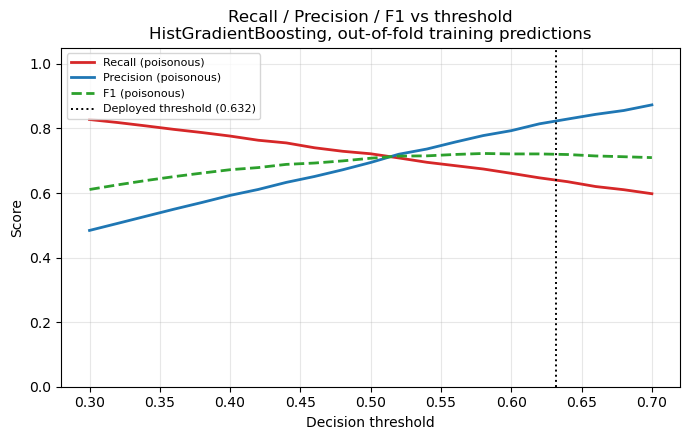

In [12]:
oof_hgb = cross_val_predict(hgb_best, X_train, y_train,
                            cv=5, method="predict_proba", n_jobs=-1)[:, 1]

thresholds = np.arange(0.30, 0.71, 0.02)
recalls, precisions, f1s = [], [], []
for t in thresholds:
    y_t = (oof_hgb >= t).astype(int)
    if y_t.sum() == 0:
        recalls.append(np.nan); precisions.append(np.nan); f1s.append(np.nan)
        continue
    recalls.append(recall_score(y_train, y_t))
    precisions.append(precision_score(y_train, y_t, zero_division=0))
    f1s.append(f1_score(y_train, y_t))

print(f"Best threshold on out-of-fold training predictions: {thresholds[np.nanargmax(f1s)]:.2f}")
print(f"Threshold selected by TunedThresholdClassifierCV:   {hgb_threshold:.4f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(thresholds, recalls,    label="Recall (poisonous)",    color="#d62728", lw=2)
ax.plot(thresholds, precisions, label="Precision (poisonous)", color="#1f77b4", lw=2)
ax.plot(thresholds, f1s,        label="F1 (poisonous)",        color="#2ca02c", lw=2, ls="--")
ax.axvline(hgb_threshold, color="black", ls=":", lw=1.4,
           label=f"Deployed threshold ({hgb_threshold:.3f})")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Score")
ax.set_title("Recall / Precision / F1 vs threshold\n"
             "HistGradientBoosting, out-of-fold training predictions")
ax.legend(fontsize=8)
ax.set_xlim(0.28, 0.72); ax.set_ylim(0, 1.05); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Final Evaluation on the Held-Out Test Set

Everything below this point uses `X_test` for the first and only time in the modelling
workflow.

### ROC and Precision-Recall Curves

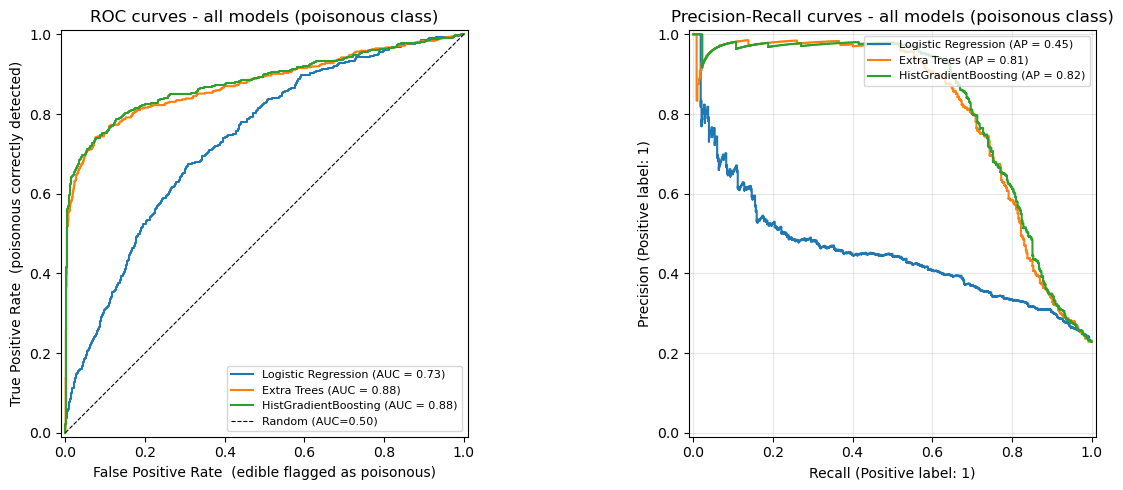

  Logistic Regression          AUC = 0.7347
  Extra Trees                  AUC = 0.8762
  HistGradientBoosting         AUC = 0.8820


In [13]:
MODELS = [
    ("Logistic Regression",  lr_grid,  y_pred_lr),
    ("Extra Trees",          et_grid,  y_pred_et),
    ("HistGradientBoosting", hgb_grid, y_pred_hgb),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name, est, _ in MODELS:
    RocCurveDisplay.from_estimator(est, X_test, y_test, pos_label=1, name=name, ax=axes[0])
axes[0].plot([0, 1], [0, 1], "k--", lw=0.8, label="Random (AUC=0.50)")
axes[0].set_title("ROC curves - all models (poisonous class)")
axes[0].set_xlabel("False Positive Rate  (edible flagged as poisonous)")
axes[0].set_ylabel("True Positive Rate  (poisonous correctly detected)")
axes[0].legend(loc="lower right", fontsize=8)

for name, est, _ in MODELS:
    PrecisionRecallDisplay.from_estimator(est, X_test, y_test, pos_label=1, name=name, ax=axes[1])
axes[1].set_title("Precision-Recall curves - all models (poisonous class)")
axes[1].legend(loc="upper right", fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

for name, est, _ in MODELS:
    auc = roc_auc_score(y_test, est.predict_proba(X_test)[:, 1])
    print(f"  {name:<28} AUC = {auc:.4f}")

### Model Comparison

**On F1 scores that appear low.** Our F1 values are pulled down by precision, not recall. That means that the models flag more edible mushrooms as poisonous.

**Why?** 

We accept false alarms in exchange for minimising the risk of calling a poisonous mushroom safe. F1 alone is therefore
not the right lens for judging these models. For the grader: we encourage to read the recall column first.

In [14]:
results = []
for name, est, y_p in MODELS:
    results.append({
        "Model":               name,
        "Recall (poison.)":    round(recall_score(y_test, y_p), 3),
        "Precision (poison.)": round(precision_score(y_test, y_p, zero_division=0), 3),
        "F1 (poison.)":        round(f1_score(y_test, y_p), 3),
        "ROC-AUC":             round(roc_auc_score(y_test, est.predict_proba(X_test)[:, 1]), 3),
    })

comparison = pd.DataFrame(results).set_index("Model")
comparison

,Recall (poison.),Precision (poison.),F1 (poison.),ROC-AUC
Model,,,,
Logistic Regression,0.674,0.389,0.493,0.735
Extra Trees,0.711,0.777,0.742,0.876
HistGradientBoosting,0.665,0.877,0.757,0.882


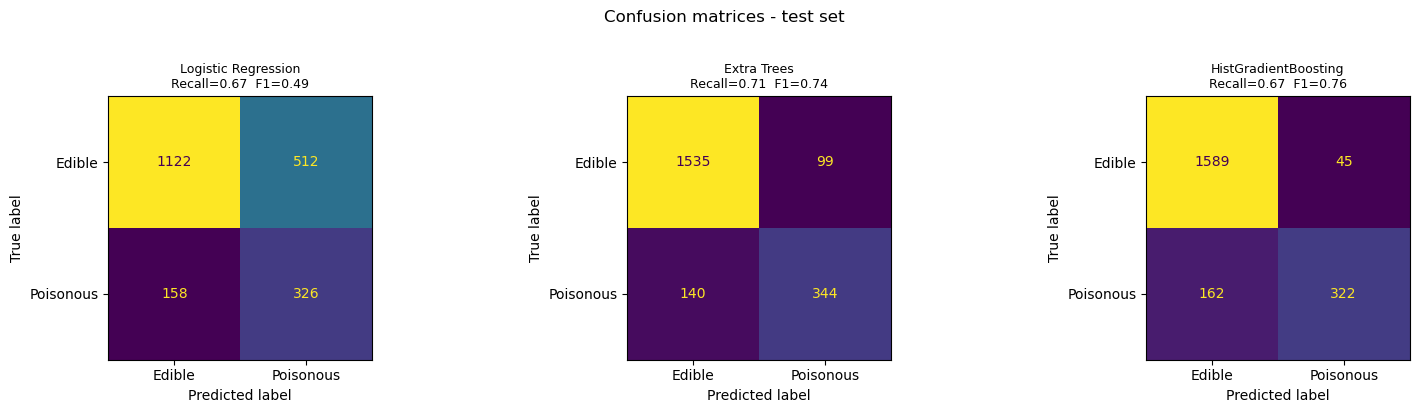

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, _, y_p) in zip(axes, MODELS):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_p),
        display_labels=["Edible", "Poisonous"],
    ).plot(ax=ax, colorbar=False)
    ax.set_title(f"{name}\nRecall={recall_score(y_test, y_p):.2f}  "
                 f"F1={f1_score(y_test, y_p):.2f}", fontsize=9)
plt.suptitle("Confusion matrices - test set", y=1.02)
plt.tight_layout()
plt.show()

## Feature Importances

Impurity-based importances from the tuned Extra Trees model.

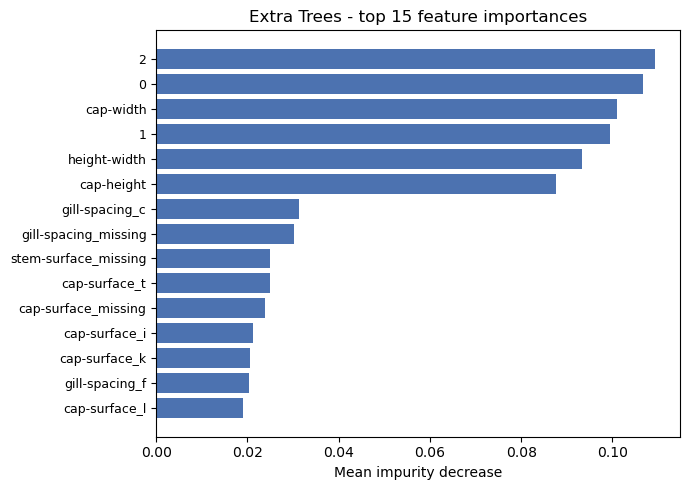

Top 5 features:
  2                                    0.1093
  0                                    0.1067
  cap-width                            0.1009
  1                                    0.0996
  height-width                         0.0934


In [16]:
ohe_cols = (et_best.named_steps["preprocessor"]
            .named_transformers_["cat"]
            .named_steps["encoder"]
            .get_feature_names_out(CATEGORICAL_ET))
feat_names = NUM_REPAIRED + list(ohe_cols)
importances = et_best.named_steps["classifier"].feature_importances_
assert len(feat_names) == len(importances), (len(feat_names), len(importances))

top_n = 15
idx = np.argsort(importances)[-top_n:]

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(range(top_n), importances[idx], color="#4C72B0")
ax.set_yticks(range(top_n))
ax.set_yticklabels([feat_names[i] for i in idx], fontsize=9)
ax.set_xlabel("Mean impurity decrease")
ax.set_title(f"Extra Trees - top {top_n} feature importances")
plt.tight_layout()
plt.show()

print("Top 5 features:")
for i in idx[-5:][::-1]:
    print(f"  {feat_names[i]:35s}  {importances[i]:.4f}")

## Obstacles Conquered

| # | Obstacle | How we overcame it |
|---:|----------|--------------------|
| 1 | **96% of rows had missing values** | Median imputation for numeric features; `"missing"` as an explicit category; all preprocessing performed inside a leakage-safe pipeline. |
| 2 | **Anonymous columns and unlabelled letter codes** | Cross-referenced the UCI and Kaggle mushroom datasets; documented all feature mappings, including unconfirmed ones (Chapter 1). |
| 3 | **Deliberately corrupted numeric data** | Identified from descriptive statistics and distribution plots; repaired by clipping, log transforms and shifts inside `MushroomRepair`, whose three data-dependent values are fitted per training fold. |
| 4 | **Severe class imbalance (77/23)** | Replaced accuracy with F1 and poisonous-class recall; `class_weight="balanced"` for all three models. |
| 5 | **Data leakage through preprocessing** | The first version computed the clip percentile and the height offset over the full dataset before splitting. Moving them into a fitted transformer removed that leak; the decision threshold is likewise selected on out-of-fold training predictions rather than on the test set. |
| 6 | **Three models needing different feature sets** | The per-model categorical lists live in `preprocessing.py` as named constants, so a model's inputs no longer depend on which notebook cell was executed last. |

## Negative Results

| Approach | Outcome | Decision |
|----------|---------|----------|
| `SelectFromModel` feature selection | F1 dropped sharply | Discarded - every feature, including the missingness-encoded ones, contributes signal. |
| Dropping rows with any NaN | Only 431 fully complete rows would remain | Ruled out immediately. |
| Accuracy as the primary metric | "Always predict edible" achieves 77% accuracy | Replaced with poisonous-class recall and F1. |
| Cleaning the numeric columns once, before the split | Inflated every reported score | Replaced by the fitted `MushroomRepair` transformer. |

### Assumptions that did not work

- SMOTENC for the random forest did not help with the missing data.
- Removing columns based on assumed relevance.
- Dropping more than 5% of the `cap-diameter` column - resulted in underfitting.

## Serialisation

Each model is saved as a `FixedThresholdClassifier` wrapping the full pipeline, so the
repairs, the imputation, the encoding and the decision threshold all travel with the
estimator. Because the pipelines contain a custom transformer, loading requires declaring
it as trusted.

In [17]:
import skops.io as sio

ARTIFACTS = {
    "pipeline_log_reg_fixed_threshold.skops":     lr_grid,
    "pipeline_extra_trees_fixed_threshold.skops": et_grid,
    "pipeline_hgb_fixed_threshold.skops":         hgb_grid,
}

for path, model in ARTIFACTS.items():
    sio.dump(model, path)
    print("saved", path)

# Loading back requires trusting the custom transformer:
path = "pipeline_hgb_fixed_threshold.skops"
print("\nuntrusted types:", sio.get_untrusted_types(file=path))
reloaded = sio.load(path, trusted=sio.get_untrusted_types(file=path))
print("reload check - identical predictions:",
      bool((reloaded.predict(X_test) == y_pred_hgb).all()))

saved pipeline_log_reg_fixed_threshold.skops
saved pipeline_extra_trees_fixed_threshold.skops
saved pipeline_hgb_fixed_threshold.skops

untrusted types: ['functools.partial', 'preprocessing.MushroomRepair', 'sklearn.compose._column_transformer._RemainderColsList', 'sklearn.utils.validation.check_array']
reload check - identical predictions: True


## Reproducibility

| Item | Value |
|------|-------|
| Dataset | `mushroom_v44_train.csv` (10,590 x 9) |
| Shared code | `preprocessing.py` - loaders, feature lists, `MushroomRepair` |
| Notebooks | `01_eda.ipynb` (forensics) then `02_modelling.ipynb` (this file) |
| Train/test split | 80/20 via `load_split()`, `random_state=42` |
| Cross-validation | 5-fold, `GridSearchCV` / `RandomizedSearchCV`, scored on F1 |
| Threshold selection | `TunedThresholdClassifierCV`, 5-fold, on the training split only |
| All `random_state` values | `42` |
| Primary metric | F1; poisonous-class recall reported separately |
| Environment | Python 3.13, scikit-learn >= 1.6 (`FrozenEstimator`), pandas, NumPy, matplotlib, seaborn, skops |
| Serialisation | `skops` (`.skops`), loaded with `trusted=[...]` |

Run order: `01_eda.ipynb`, then this notebook top to bottom from a fresh kernel.

*Prepared by Group G - I. Solovei, M. Triapitsina, S. Hmyria.*